# CLTV y Acciones Comerciales — Churn Prediction
**Universidad Alfonso X el Sabio (UAX)**


En este notebook calculamos el **Customer Lifetime Value (CLTV)** de cada nuevo cliente, los segmentamos por riesgo y valor, y diseñamos acciones comerciales concretas con su correspondiente análisis de rentabilidad (ROI).


## 1. Librerías y configuración visual


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# ── Paleta corporativa UAX ──────────────────────────────────
UAX_NAVY    = '#1B2A4A'
UAX_GOLD    = '#C8A951'
UAX_LIGHT   = '#E8E0D0'
UAX_GREY    = '#6B7B8D'
UAX_ACCENT  = '#3A5BA0'
UAX_RED     = '#C0392B'
UAX_GREEN   = '#27AE60'

uax_palette = [UAX_NAVY, UAX_GOLD, UAX_ACCENT, UAX_GREY]

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.edgecolor':   UAX_GREY,
    'axes.labelcolor':  UAX_NAVY,
    'text.color':       UAX_NAVY,
    'xtick.color':      UAX_GREY,
    'ytick.color':      UAX_GREY,
    'grid.color':       '#E0E0E0',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'sans-serif',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'figure.titlesize': 16,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  UAX_GREY,
})
sns.set_style('white')
print('✓ Configuración visual UAX cargada')


✓ Configuración visual UAX cargada


## 2. Carga de datos


In [19]:
# Tabla de costes por modelo
costes = pd.read_csv('data/lake/costes.csv')
display(costes)

# Nuevos clientes con predicciones del notebook anterior
new_customers = pd.read_csv('data/lake/nuevos_clientes.csv')
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in new_customers.columns:
        new_customers[col] = pd.to_datetime(new_customers[col], errors='coerce', dayfirst=True, format='%d/%m/%Y')

# Cargar modelo y threshold
xgboost_model  = joblib.load('data/warehouse/xgboost.pkl')
full_pipeline  = joblib.load('data/warehouse/num_pipeline.pkl')
BEST_THRESHOLD = joblib.load('data/warehouse/best_threshold.pkl')

print(f'Nuevos clientes: {new_customers.shape[0]:,}')
print(f'Modelos en tabla de costes: {costes["Modelo"].tolist()}')


,Modelo,Margen,Costetransporte,Margendistribuidor,GastosMarketing,Mantenimiento_medio,Comisión_Marca
0,A,28.0,250.0,5.0,5.0,250.0,2.0
1,B,33.0,250.0,5.0,5.0,263.0,2.0
2,C,33.0,250.0,5.0,25.0,276.0,5.0
3,D,33.0,250.0,5.0,25.0,290.0,5.0
4,E,37.0,250.0,5.0,25.0,305.0,5.0
5,F,42.0,250.0,5.0,25.0,320.0,5.0
6,G,42.0,250.0,5.0,25.0,336.0,5.0
7,H,42.0,250.0,5.0,25.0,353.0,5.0
8,I,43.0,250.0,5.0,5.0,371.0,8.0
9,J,5.0,250.0,5.0,25.0,390.0,8.0


Nuevos clientes: 10,000
Modelos en tabla de costes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


## 3. Obtener probabilidades de churn


In [20]:
# Alinear esquema (mismo proceso que en model_verification)
rename_map = {'Lead_compra_1': 'Fue_Lead'}
new_customers = new_customers.rename(columns={k: v for k, v in rename_map.items() if k in new_customers.columns})

# Cargar test_set para referencia de columnas
test_set = pd.read_csv('data/warehouse/test_set.csv')
for col in ['Sales_Date', 'FIN_GARANTIA', 'BASE_DATE']:
    if col in test_set.columns:
        test_set[col] = pd.to_datetime(test_set[col], errors='coerce')

if 'Churn_400' not in new_customers.columns:
    new_customers['Churn_400'] = 'N'
if 'DAYS_LAST_SERVICE' not in new_customers.columns:
    new_customers['DAYS_LAST_SERVICE'] = np.nan

extra_cols = set(new_customers.columns) - set(test_set.columns)
if extra_cols:
    new_customers = new_customers.drop(columns=extra_cols)

missing_cols = set(test_set.columns) - set(new_customers.columns)
for col in missing_cols:
    new_customers[col] = np.nan

new_customers = new_customers[test_set.columns]

# Transformar y predecir
new_prepared = full_pipeline.fit_transform(new_customers)
if 'Churn_400' in new_prepared.columns:
    X_new = new_prepared.drop(columns=['Churn_400'])
else:
    X_new = new_prepared

new_proba = xgboost_model.predict_proba(X_new)[:, 1]

# Construir dataframe de trabajo
df = new_prepared.copy()
df['p_churn'] = new_proba
df['CODE'] = new_customers.loc[new_prepared.index, 'CODE'].values
df['Modelo_letra'] = new_customers.loc[new_prepared.index, 'Modelo'].values
df['Id_Producto'] = new_customers.loc[new_prepared.index, 'Id_Producto'].values
df['PVP_original'] = new_customers.loc[new_prepared.index, 'PVP'].values

print(f'Clientes con predicción: {len(df):,}')
print(f'P(churn) media: {df["p_churn"].mean():.4f}')
print(f'Modelos presentes: {sorted(df["Modelo_letra"].unique())}')


Clientes con predicción: 10,000
P(churn) media: 0.2990
Modelos presentes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']


## 4. Cálculo del CLTV (Customer Lifetime Value)


### Fórmula del coste de mantenimiento

El ingreso por la revisión `n` de un cliente es:

**C(n) = BASE × (1 + α)^n**

Donde:
- `BASE` = Mantenimiento_medio de la tabla de costes según el modelo del coche
- α = 7% para modelos A y B, 10% para el resto
- n = número de revisión (empezamos en n=1 para los nuevos clientes)

### Costes fijos por revisión
- 1% Marketing
- 30% Costes fijos
- 7% Comisión de marca
- **Total: 38% del ingreso bruto**

### Beneficio neto por revisión
**Beneficio(n) = C(n) × 0.62**

### CLTV con probabilidad de supervivencia
Para incorporar el riesgo de churn, cada revisión futura se pondera por la probabilidad de que el cliente siga activo:

**CLTV = Σ (n=1 hasta N) [ Beneficio(n) × (1 − p_churn)^n ]**

Un cliente con alta probabilidad de churn verá su CLTV reducido porque es probable que se vaya antes de las revisiones más caras.


In [21]:
# ── Parámetros ───────────────────────────────────────────────
HORIZONTE_REVISIONES = 10   # simulamos hasta 10 revisiones futuras
COSTES_FIJOS_PCT     = 0.38 # 1% marketing + 30% fijos + 7% comisión
MARGEN_NETO_PCT      = 1 - COSTES_FIJOS_PCT  # 0.62

# Alpha por modelo
ALPHA_AB    = 0.07
ALPHA_RESTO = 0.10

# Mapear BASE (Mantenimiento_medio) y alpha por modelo
costes_dict = costes.set_index('Modelo')['Mantenimiento_medio'].to_dict()

def get_alpha(modelo):
    return ALPHA_AB if modelo in ['A', 'B'] else ALPHA_RESTO

def calcular_cltv(row):
    modelo = row['Modelo_letra']
    p_churn = row['p_churn']
    base = costes_dict.get(modelo, 300)  # fallback si modelo no existe
    alpha = get_alpha(modelo)
    
    cltv = 0
    desglose = []
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso_bruto = base * (1 + alpha) ** n
        beneficio_neto = ingreso_bruto * MARGEN_NETO_PCT
        prob_supervivencia = (1 - p_churn) ** n
        beneficio_ponderado = beneficio_neto * prob_supervivencia
        cltv += beneficio_ponderado
        desglose.append({
            'n': n,
            'ingreso_bruto': ingreso_bruto,
            'beneficio_neto': beneficio_neto,
            'p_supervivencia': prob_supervivencia,
            'beneficio_ponderado': beneficio_ponderado,
        })
    
    return cltv

# Calcular CLTV para cada cliente
df['CLTV'] = df.apply(calcular_cltv, axis=1)

print(f'CLTV medio: {df["CLTV"].mean():,.0f} €')
print(f'CLTV mediano: {df["CLTV"].median():,.0f} €')
print(f'Rango: {df["CLTV"].min():,.0f} € — {df["CLTV"].max():,.0f} €')


CLTV medio: 847 €
CLTV mediano: 555 €
Rango: 56 € — 3,462 €


### 4.1 Ejemplo detallado: desglose de revisiones


In [22]:
# Ejemplo con un cliente de modelo D (α=10%, BASE=290€)
ejemplo_base = 290
ejemplo_alpha = 0.10
ejemplo_pchurn_bajo = 0.03
ejemplo_pchurn_alto = 0.15

rows = []
for n in range(1, HORIZONTE_REVISIONES + 1):
    ingreso = ejemplo_base * (1 + ejemplo_alpha) ** n
    benef = ingreso * MARGEN_NETO_PCT
    surv_bajo = (1 - ejemplo_pchurn_bajo) ** n
    surv_alto = (1 - ejemplo_pchurn_alto) ** n
    rows.append({
        'Revisión': n,
        'Ingreso bruto': f'{ingreso:,.0f} €',
        'Beneficio neto': f'{benef:,.0f} €',
        'P(activo) bajo riesgo': f'{surv_bajo:.1%}',
        'P(activo) alto riesgo': f'{surv_alto:.1%}',
        'CLTV acum. bajo': f'{benef * surv_bajo:,.0f} €',
        'CLTV acum. alto': f'{benef * surv_alto:,.0f} €',
    })

df_ejemplo = pd.DataFrame(rows)
display(df_ejemplo)


,Revisión,Ingreso bruto,Beneficio neto,P(activo) bajo riesgo,P(activo) alto riesgo,CLTV acum. bajo,CLTV acum. alto
0,1,319 €,198 €,97.0%,85.0%,192 €,168 €
1,2,351 €,218 €,94.1%,72.2%,205 €,157 €
2,3,386 €,239 €,91.3%,61.4%,218 €,147 €
3,4,425 €,263 €,88.5%,52.2%,233 €,137 €
4,5,467 €,290 €,85.9%,44.4%,249 €,128 €
5,6,514 €,319 €,83.3%,37.7%,265 €,120 €
6,7,565 €,350 €,80.8%,32.1%,283 €,112 €
7,8,622 €,385 €,78.4%,27.2%,302 €,105 €
8,9,684 €,424 €,76.0%,23.2%,322 €,98 €
9,10,752 €,466 €,73.7%,19.7%,344 €,92 €


Se ve claramente cómo el cliente de alto riesgo pierde valor en cada revisión futura: aunque los precios suben (por el factor α), la probabilidad de que siga viniendo baja mucho más rápido.


### 4.2 Distribución del CLTV


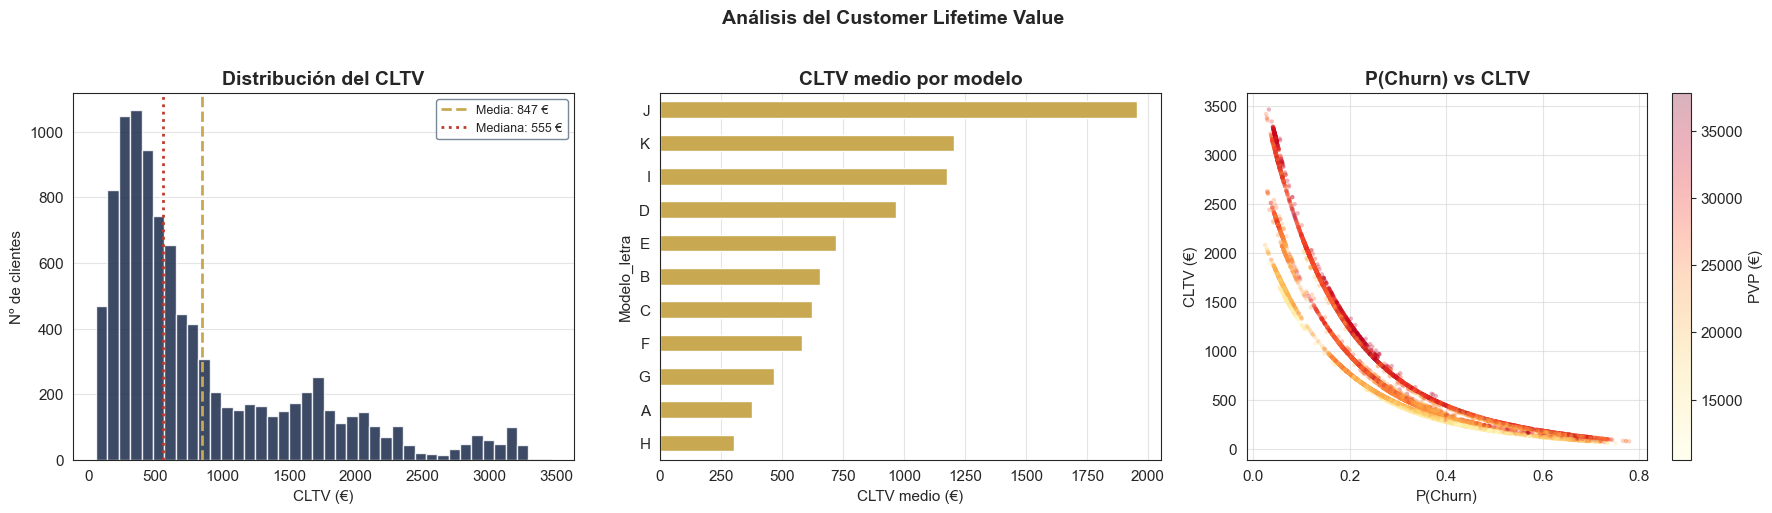

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma general
ax = axes[0]
ax.hist(df['CLTV'], bins=40, color=UAX_NAVY, edgecolor='white', alpha=0.85)
ax.axvline(df['CLTV'].mean(), color=UAX_GOLD, linestyle='--', lw=2, label=f'Media: {df["CLTV"].mean():,.0f} €')
ax.axvline(df['CLTV'].median(), color=UAX_RED, linestyle=':', lw=2, label=f'Mediana: {df["CLTV"].median():,.0f} €')
ax.set_xlabel('CLTV (€)')
ax.set_ylabel('Nº de clientes')
ax.set_title('Distribución del CLTV')
ax.legend(fontsize=9)
ax.grid(axis='y')

# CLTV por modelo
ax = axes[1]
cltv_by_model = df.groupby('Modelo_letra')['CLTV'].mean().sort_values()
cltv_by_model.plot(kind='barh', color=UAX_GOLD, edgecolor='white', ax=ax)
ax.set_xlabel('CLTV medio (€)')
ax.set_title('CLTV medio por modelo')
ax.grid(axis='x')

# Scatter: p_churn vs CLTV
ax = axes[2]
scatter = ax.scatter(df['p_churn'], df['CLTV'], c=df['PVP_original'], cmap='YlOrRd',
                     alpha=0.3, s=10, edgecolors='none')
ax.set_xlabel('P(Churn)')
ax.set_ylabel('CLTV (€)')
ax.set_title('P(Churn) vs CLTV')
plt.colorbar(scatter, ax=ax, label='PVP (€)')
ax.grid(True)

plt.suptitle('Análisis del Customer Lifetime Value', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Segmentación: Riesgo × Valor


Creamos una matriz de segmentación cruzando dos dimensiones:
- **Riesgo de churn**: basado en la probabilidad predicha (percentiles)
- **Valor del cliente**: basado en el CLTV calculado (percentiles)

Esto genera 9 segmentos con estrategias diferenciadas.


In [24]:
# ── Definir segmentos ────────────────────────────────────────
# Riesgo: basado en percentiles de p_churn
df['riesgo'] = pd.qcut(df['p_churn'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Valor: basado en percentiles de CLTV
df['valor'] = pd.qcut(df['CLTV'], q=3, labels=['Bajo', 'Medio', 'Alto'])

# Segmento combinado
df['segmento'] = df['riesgo'].astype(str) + ' riesgo / ' + df['valor'].astype(str) + ' valor'

print('Distribución de segmentos:')
print(df.groupby(['riesgo', 'valor']).size().unstack(fill_value=0))
print(f'\nTotal clientes segmentados: {len(df):,}')


Distribución de segmentos:
valor   Bajo  Medio  Alto
riesgo                   
Bajo       0    245  3089
Medio    341   2746   245
Alto    2992    342     0

Total clientes segmentados: 10,000


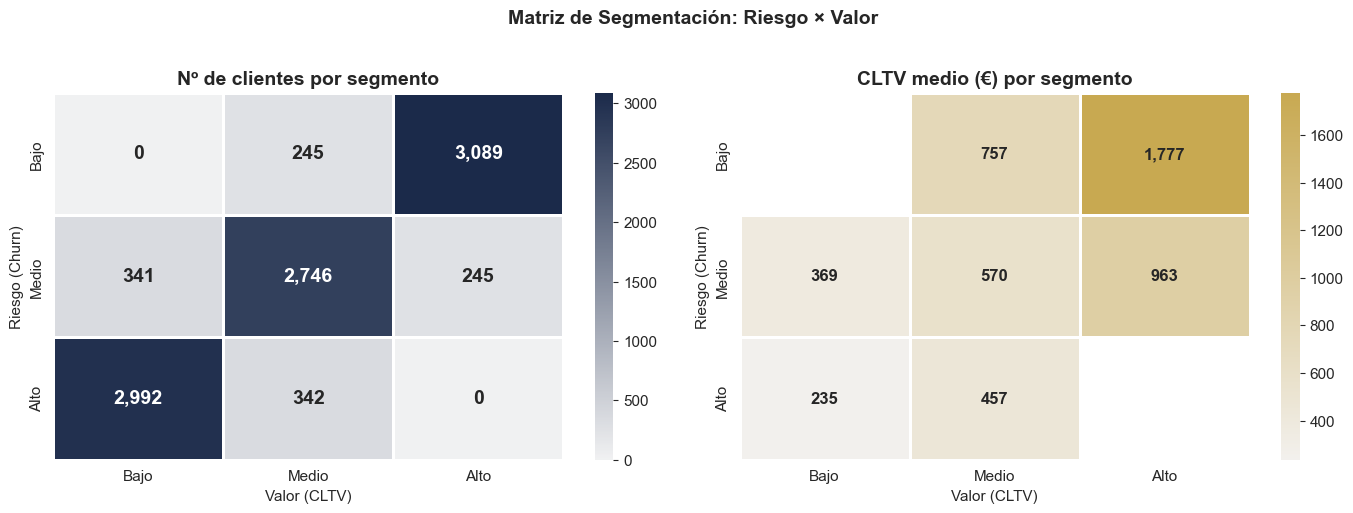

In [25]:
# Visualización de la matriz
pivot_count = df.groupby(['riesgo', 'valor']).size().unstack(fill_value=0)
pivot_cltv  = df.groupby(['riesgo', 'valor'])['CLTV'].mean().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
ax = axes[0]
sns.heatmap(pivot_count, annot=True, fmt=',d', cmap=sns.light_palette(UAX_NAVY, as_cmap=True),
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
ax.set_title('Nº de clientes por segmento')
ax.set_xlabel('Valor (CLTV)')
ax.set_ylabel('Riesgo (Churn)')

# CLTV medio
ax = axes[1]
sns.heatmap(pivot_cltv, annot=True, fmt=',.0f', cmap=sns.light_palette(UAX_GOLD, as_cmap=True),
            linewidths=1, linecolor='white', ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('CLTV medio (€) por segmento')
ax.set_xlabel('Valor (CLTV)')
ax.set_ylabel('Riesgo (Churn)')

plt.suptitle('Matriz de Segmentación: Riesgo × Valor', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Asignación de acciones comerciales


### Reglas de negocio

| Segmento | Acción | Descripción | Coste estimado |
|---|---|---|---|
| **Alto riesgo / Alto valor** | Retención agresiva | Revisión gratuita + descuento 15% en siguiente | Coste de 1 revisión + 15% dto |
| **Alto riesgo / Medio valor** | Retención proactiva | Descuento 10% en próxima revisión | 10% del ingreso rev. 1 |
| **Alto riesgo / Bajo valor** | Contacto mínimo | Email de seguimiento (coste ~0) | 0 € |
| **Medio riesgo / Alto valor** | Fidelización premium | Pack mantenimiento con 5% dto | 5% del ingreso rev. 1 |
| **Medio riesgo / Medio valor** | Incentivo moderado | Descuento 5% en revisión | 5% del ingreso rev. 1 |
| **Medio riesgo / Bajo valor** | Seguimiento estándar | Recordatorio de revisión | 0 € |
| **Bajo riesgo / Alto valor** | Upselling | Oferta extensión garantía o seguro batería | 0 € (genera ingreso) |
| **Bajo riesgo / Medio valor** | Mantenimiento | Comunicación periódica | 0 € |
| **Bajo riesgo / Bajo valor** | Sin acción | — | 0 € |

Además, para clientes con **n ≥ 5 revisiones** y CLTV medio-alto, se aplica un **descuento de 1.000€ para segundo vehículo**. Como nuestros clientes son nuevos (n=0), esta regla se activará en el futuro.


In [26]:
# ── Calcular coste de la revisión 1 para cada cliente ────────
def coste_revision_n(modelo, n):
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    return base * (1 + alpha) ** n

df['ingreso_rev1'] = df['Modelo_letra'].apply(lambda m: coste_revision_n(m, 1))

# ── Asignar acción comercial ────────────────────────────────
def asignar_accion(row):
    r = row['riesgo']
    v = row['valor']
    rev1 = row['ingreso_rev1']
    
    if r == 'Alto' and v == 'Alto':
        return 'Retención agresiva', rev1 + rev1 * 0.15, 'Revisión gratuita + 15% dto en siguiente'
    elif r == 'Alto' and v == 'Medio':
        return 'Retención proactiva', rev1 * 0.10, '10% dto en próxima revisión'
    elif r == 'Alto' and v == 'Bajo':
        return 'Contacto mínimo', 0, 'Email de seguimiento'
    elif r == 'Medio' and v == 'Alto':
        return 'Fidelización premium', rev1 * 0.05, 'Pack mantenimiento con 5% dto'
    elif r == 'Medio' and v == 'Medio':
        return 'Incentivo moderado', rev1 * 0.05, '5% dto en revisión'
    elif r == 'Medio' and v == 'Bajo':
        return 'Seguimiento estándar', 0, 'Recordatorio de revisión'
    elif r == 'Bajo' and v == 'Alto':
        return 'Upselling', 0, 'Oferta ext. garantía / seguro batería'
    elif r == 'Bajo' and v == 'Medio':
        return 'Mantenimiento', 0, 'Comunicación periódica'
    else:
        return 'Sin acción', 0, '—'

acciones = df.apply(asignar_accion, axis=1, result_type='expand')
df['accion'] = acciones[0]
df['coste_accion'] = acciones[1]
df['descripcion_accion'] = acciones[2]

print('Distribución de acciones:')
resumen_acciones = df.groupby('accion').agg(
    clientes=('CODE', 'count'),
    coste_medio=('coste_accion', 'mean'),
    coste_total=('coste_accion', 'sum'),
    CLTV_medio=('CLTV', 'mean'),
    p_churn_medio=('p_churn', 'mean'),
).sort_values('coste_total', ascending=False)

resumen_acciones['coste_medio'] = resumen_acciones['coste_medio'].round(2)
resumen_acciones['coste_total'] = resumen_acciones['coste_total'].round(0)
resumen_acciones['CLTV_medio'] = resumen_acciones['CLTV_medio'].round(0)
resumen_acciones['p_churn_medio'] = resumen_acciones['p_churn_medio'].round(4)

display(resumen_acciones)


Distribución de acciones:


,clientes,coste_medio,coste_total,CLTV_medio,p_churn_medio
accion,,,,,
Incentivo moderado,2746,15.52,42631.0,570.0,0.2865
Retención proactiva,342,38.91,13308.0,457.0,0.3816
Fidelización premium,245,20.50,5022.0,963.0,0.2440
Contacto mínimo,2992,0.00,0.0,235.0,0.4948
Mantenimiento,245,0.00,0.0,757.0,0.2022
Seguimiento estándar,341,0.00,0.0,369.0,0.3429
Upselling,3089,0.00,0.0,1777.0,0.1185


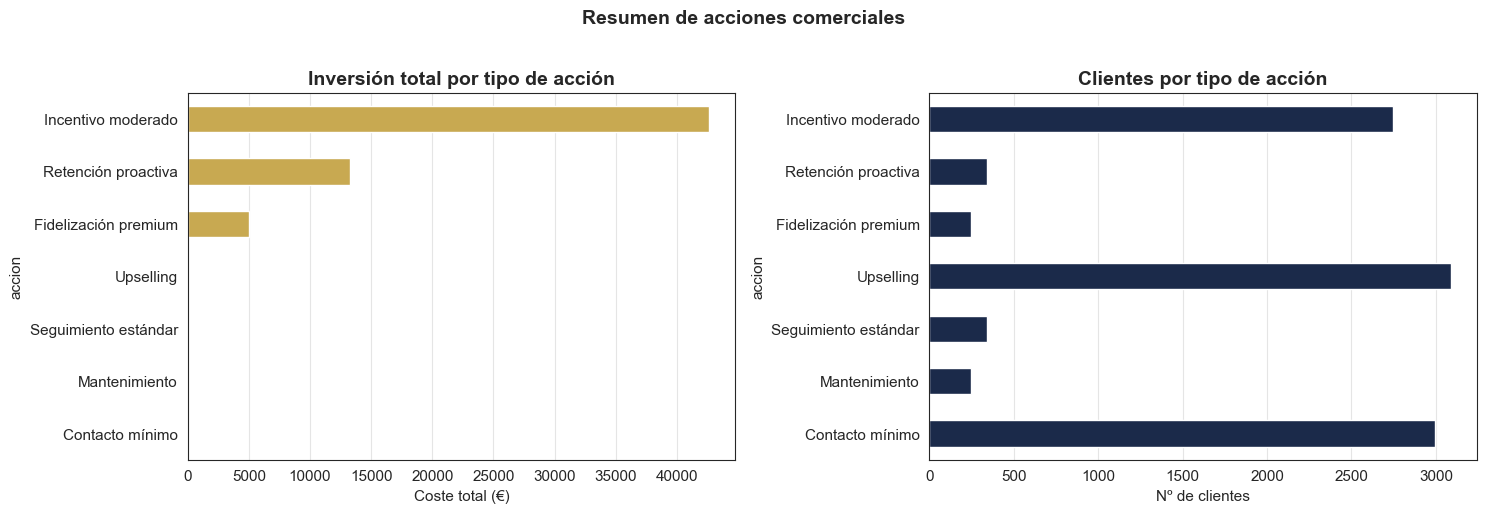

In [27]:
# Visualización de acciones
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Coste total por acción
ax = axes[0]
resumen_plot = resumen_acciones.sort_values('coste_total')
resumen_plot['coste_total'].plot(kind='barh', color=UAX_GOLD, edgecolor='white', ax=ax)
ax.set_xlabel('Coste total (€)')
ax.set_title('Inversión total por tipo de acción')
ax.grid(axis='x')

# Clientes por acción
ax = axes[1]
resumen_plot['clientes'].plot(kind='barh', color=UAX_NAVY, edgecolor='white', ax=ax)
ax.set_xlabel('Nº de clientes')
ax.set_title('Clientes por tipo de acción')
ax.grid(axis='x')

plt.suptitle('Resumen de acciones comerciales', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Simulación económica — ROI de las acciones


Simulamos el impacto de cada acción asumiendo que reduce la probabilidad de churn en un porcentaje estimado:

| Acción | Reducción estimada de p_churn |
|---|---|
| Retención agresiva | −50% |
| Retención proactiva | −30% |
| Fidelización premium | −20% |
| Incentivo moderado | −15% |
| Upselling | −10% |
| Contacto mínimo / Seguimiento | −5% |
| Sin acción | 0% |

Con esto recalculamos el CLTV post-acción y medimos el ROI.


In [28]:
# ── Simulación de impacto ────────────────────────────────────
REDUCCION_CHURN = {
    'Retención agresiva':    0.50,
    'Retención proactiva':   0.30,
    'Fidelización premium':  0.20,
    'Incentivo moderado':    0.15,
    'Upselling':             0.10,
    'Seguimiento estándar':  0.05,
    'Contacto mínimo':       0.05,
    'Mantenimiento':         0.05,
    'Sin acción':            0.00,
}

def calcular_cltv_con_pchurn(row, p_churn):
    modelo = row['Modelo_letra']
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    
    cltv = 0
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso_bruto = base * (1 + alpha) ** n
        beneficio_neto = ingreso_bruto * MARGEN_NETO_PCT
        prob_supervivencia = (1 - p_churn) ** n
        cltv += beneficio_neto * prob_supervivencia
    return cltv

# CLTV sin acción (ya calculado)
df['CLTV_sin_accion'] = df['CLTV']

# CLTV con acción (p_churn reducido)
def cltv_post_accion(row):
    reduccion = REDUCCION_CHURN.get(row['accion'], 0)
    p_churn_new = row['p_churn'] * (1 - reduccion)
    return calcular_cltv_con_pchurn(row, p_churn_new)

df['CLTV_con_accion'] = df.apply(cltv_post_accion, axis=1)
df['ganancia_cltv'] = df['CLTV_con_accion'] - df['CLTV_sin_accion']

# ROI: cuánto ganamos por cada euro invertido
df['ROI'] = np.where(
    df['coste_accion'] > 0,
    (df['ganancia_cltv'] - df['coste_accion']) / df['coste_accion'],
    np.nan  # sin coste → no aplica ROI
)

print('=== RESUMEN ECONÓMICO ===')
print(f'Inversión total en acciones:  {df["coste_accion"].sum():>12,.0f} €')
print(f'Ganancia de CLTV esperada:    {df["ganancia_cltv"].sum():>12,.0f} €')
print(f'Beneficio neto de las acciones: {df["ganancia_cltv"].sum() - df["coste_accion"].sum():>12,.0f} €')
print(f'ROI medio (acciones con coste): {df.loc[df["coste_accion"] > 0, "ROI"].mean():>10.1f}x')


=== RESUMEN ECONÓMICO ===
Inversión total en acciones:        60,961 €
Ganancia de CLTV esperada:       1,011,908 €
Beneficio neto de las acciones:      950,948 €
ROI medio (acciones con coste):        8.3x


In [29]:
# Simulación por acción
sim = df.groupby('accion').agg(
    clientes=('CODE', 'count'),
    inversion=('coste_accion', 'sum'),
    ganancia_cltv=('ganancia_cltv', 'sum'),
    roi_medio=('ROI', 'mean'),
).round(0)

sim['beneficio_neto'] = sim['ganancia_cltv'] - sim['inversion']
sim = sim.sort_values('beneficio_neto', ascending=False)
display(sim)


,clientes,inversion,ganancia_cltv,roi_medio,beneficio_neto
accion,,,,,
Upselling,3089,0.0,339791.0,NaN,339791.0
Incentivo moderado,2746,42631.0,382239.0,8.0,339608.0
Retención proactiva,342,13308.0,119451.0,8.0,106143.0
Contacto mínimo,2992,0.0,77373.0,NaN,77373.0
Fidelización premium,245,5022.0,72251.0,13.0,67229.0
Seguimiento estándar,341,0.0,10539.0,NaN,10539.0
Mantenimiento,245,0.0,10265.0,NaN,10265.0


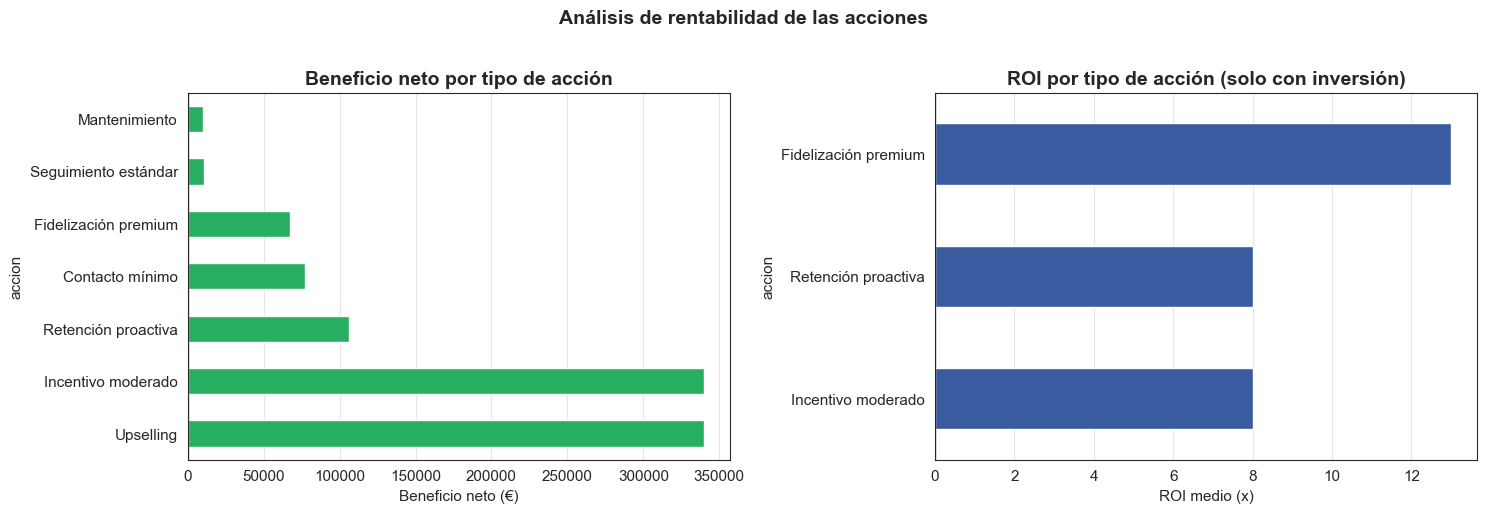

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Beneficio neto por acción
ax = axes[0]
colors_bn = [UAX_GREEN if v > 0 else UAX_RED for v in sim['beneficio_neto']]
sim['beneficio_neto'].plot(kind='barh', color=colors_bn, edgecolor='white', ax=ax)
ax.set_xlabel('Beneficio neto (€)')
ax.set_title('Beneficio neto por tipo de acción')
ax.axvline(x=0, color=UAX_GREY, linewidth=1)
ax.grid(axis='x')

# ROI por acción (solo las que tienen coste)
ax = axes[1]
roi_data = sim[sim['inversion'] > 0]['roi_medio'].sort_values()
roi_data.plot(kind='barh', color=UAX_ACCENT, edgecolor='white', ax=ax)
ax.set_xlabel('ROI medio (x)')
ax.set_title('ROI por tipo de acción (solo con inversión)')
ax.axvline(x=0, color=UAX_GREY, linewidth=1)
ax.grid(axis='x')

plt.suptitle('Análisis de rentabilidad de las acciones', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 8. Proyección de revisiones futuras y descuento 2º vehículo


Aunque los clientes actuales tienen 0 revisiones, proyectamos cuándo alcanzarán n≥5 y serán elegibles para el descuento de 1.000€ en segundo vehículo.


In [31]:
# ── Tabla de costes de revisión por modelo (revisiones 1 a 10) ─────
modelos_unicos = sorted(df['Modelo_letra'].unique())

tabla_revisiones = []
for modelo in modelos_unicos:
    base = costes_dict.get(modelo, 300)
    alpha = get_alpha(modelo)
    for n in range(1, HORIZONTE_REVISIONES + 1):
        ingreso = base * (1 + alpha) ** n
        coste_fijo = ingreso * COSTES_FIJOS_PCT
        beneficio = ingreso * MARGEN_NETO_PCT
        tabla_revisiones.append({
            'Modelo': modelo,
            'Revisión': n,
            'Ingreso bruto': round(ingreso, 2),
            'Costes fijos (38%)': round(coste_fijo, 2),
            'Beneficio neto': round(beneficio, 2),
            'Elegible dto 2º veh.': '✓ Sí' if n >= 5 else '',
        })

df_rev = pd.DataFrame(tabla_revisiones)

# Mostrar resumen pivotado
pivot_rev = df_rev.pivot_table(index='Modelo', columns='Revisión', values='Beneficio neto')
print('Beneficio neto por revisión (€):')
display(pivot_rev.round(0).astype(int))


Beneficio neto por revisión (€):


Revisión,1,2,3,4,5,6,7,8,9,10
Modelo,,,,,,,,,,
A,166,177,190,203,217,233,249,266,285,305
B,174,187,200,214,229,245,262,280,300,321
C,188,207,228,251,276,303,333,367,403,444
D,198,218,239,263,290,319,350,385,424,466
E,208,229,252,277,305,335,368,405,446,490
F,218,240,264,290,320,351,387,425,468,515
G,229,252,277,305,336,369,406,447,491,540
H,241,265,291,320,352,388,426,469,516,568
I,253,278,306,337,370,407,448,493,542,597


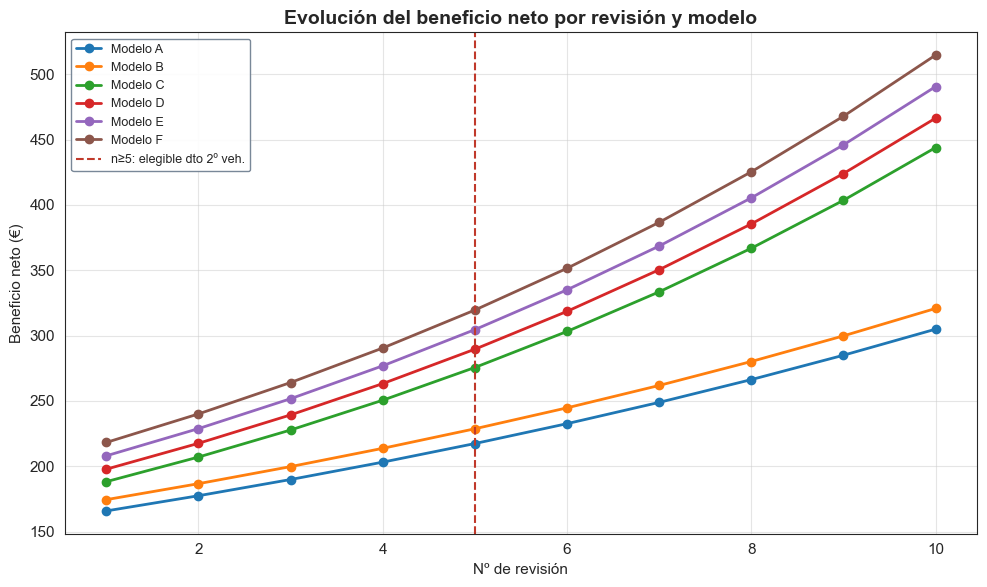

In [32]:
# Visualizar la curva de ingresos por modelo
fig, ax = plt.subplots(figsize=(10, 6))

for modelo in modelos_unicos[:6]:  # top 6 para no saturar
    subset = df_rev[df_rev['Modelo'] == modelo]
    ax.plot(subset['Revisión'], subset['Beneficio neto'], 'o-', lw=2, label=f'Modelo {modelo}')

ax.axvline(x=5, color=UAX_RED, linestyle='--', lw=1.5, label='n≥5: elegible dto 2º veh.')
ax.set_xlabel('Nº de revisión')
ax.set_ylabel('Beneficio neto (€)')
ax.set_title('Evolución del beneficio neto por revisión y modelo')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()


A partir de la revisión 5, los ingresos por mantenimiento son lo suficientemente altos como para que un descuento de 1.000€ en segundo vehículo sea una inversión rentable si el cliente tiene CLTV medio-alto.


## 9. Exportar resultados


In [33]:
# Tabla final de clientes con acciones
output_cols = ['CODE', 'Modelo_letra', 'PVP_original', 'p_churn', 'riesgo', 'valor',
               'segmento', 'CLTV', 'accion', 'descripcion_accion', 'coste_accion',
               'CLTV_con_accion', 'ganancia_cltv', 'ROI']

df_export = df[output_cols].copy()
df_export = df_export.sort_values('CLTV', ascending=False)

df_export.to_csv('data/warehouse/clientes_acciones_comerciales.csv', index=False)
print(f'✓ Exportado: data/warehouse/clientes_acciones_comerciales.csv ({len(df_export):,} filas)')
df_export.head(10)


✓ Exportado: data/warehouse/clientes_acciones_comerciales.csv (10,000 filas)


,CODE,Modelo_letra,PVP_original,p_churn,riesgo,valor,segmento,CLTV,accion,descripcion_accion,coste_accion,CLTV_con_accion,ganancia_cltv,ROI
3741,SYN003741,J,34448,0.032424,Bajo,Alto,Bajo riesgo / Alto valor,3461.991866,Upselling,Oferta ext. garantía / seguro batería,0.0,3532.475452,70.483586,NaN
1522,SYN001522,I,26002,0.026621,Bajo,Alto,Bajo riesgo / Alto valor,3414.356430,Upselling,Oferta ext. garantía / seguro batería,0.0,3471.434226,57.077796,NaN
6074,SYN006074,I,28161,0.028301,Bajo,Alto,Bajo riesgo / Alto valor,3378.827042,Upselling,Oferta ext. garantía / seguro batería,0.0,3438.876237,60.049195,NaN
5084,SYN005084,I,23798,0.028933,Bajo,Alto,Bajo riesgo / Alto valor,3365.572922,Upselling,Oferta ext. garantía / seguro batería,0.0,3426.721316,61.148394,NaN
2892,SYN002892,I,27310,0.029602,Bajo,Alto,Bajo riesgo / Alto valor,3351.608903,Upselling,Oferta ext. garantía / seguro batería,0.0,3413.909878,62.300975,NaN
9966,SYN009966,J,30246,0.038247,Bajo,Alto,Bajo riesgo / Alto valor,3339.120134,Upselling,Oferta ext. garantía / seguro batería,0.0,3419.294461,80.174327,NaN
5386,SYN005386,J,30892,0.040833,Bajo,Alto,Bajo riesgo / Alto valor,3286.044141,Upselling,Oferta ext. garantía / seguro batería,0.0,3370.268074,84.223933,NaN
1431,SYN001431,J,32990,0.040892,Bajo,Alto,Bajo riesgo / Alto valor,3284.829250,Upselling,Oferta ext. garantía / seguro batería,0.0,3369.144893,84.315643,NaN
649,SYN000649,J,34133,0.040986,Bajo,Alto,Bajo riesgo / Alto valor,3282.929117,Upselling,Oferta ext. garantía / seguro batería,0.0,3367.388108,84.458991,NaN
6240,SYN006240,J,31208,0.041081,Bajo,Alto,Bajo riesgo / Alto valor,3281.004492,Upselling,Oferta ext. garantía / seguro batería,0.0,3365.608569,84.604077,NaN


## 10. Resumen ejecutivo


In [34]:
print('=' * 70)
print('RESUMEN EJECUTIVO — PLAN DE ACCIONES COMERCIALES')
print('=' * 70)
print(f'')
print(f'Clientes analizados:        {len(df):>8,}')
print(f'CLTV medio:                 {df["CLTV"].mean():>8,.0f} €')
print(f'CLTV total (cartera):       {df["CLTV"].sum():>8,.0f} €')
print(f'')
print(f'Inversión propuesta:        {df["coste_accion"].sum():>8,.0f} €')
print(f'Ganancia CLTV esperada:     {df["ganancia_cltv"].sum():>8,.0f} €')
print(f'Beneficio neto:             {df["ganancia_cltv"].sum() - df["coste_accion"].sum():>8,.0f} €')
print(f'')

clientes_con_accion = (df['coste_accion'] > 0).sum()
print(f'Clientes con acción activa: {clientes_con_accion:>8,} ({clientes_con_accion/len(df)*100:.1f}%)')
print(f'Clientes sin acción/coste:  {len(df) - clientes_con_accion:>8,} ({(len(df)-clientes_con_accion)/len(df)*100:.1f}%)')
print(f'')
print(f'ROI medio (acciones con coste): {df.loc[df["coste_accion"] > 0, "ROI"].mean():.1f}x')
print('=' * 70)


RESUMEN EJECUTIVO — PLAN DE ACCIONES COMERCIALES

Clientes analizados:          10,000
CLTV medio:                      847 €
CLTV total (cartera):       8,465,018 €

Inversión propuesta:          60,961 €
Ganancia CLTV esperada:     1,011,908 €
Beneficio neto:              950,948 €

Clientes con acción activa:    3,333 (33.3%)
Clientes sin acción/coste:     6,667 (66.7%)

ROI medio (acciones con coste): 8.3x


### Decisiones clave

1. **Concentrar la inversión** en clientes de alto riesgo + alto valor (retención agresiva) — es donde el ROI es mayor.
2. **No gastar** en clientes de bajo valor — el coste de retención no se justifica.
3. **Upselling** a clientes de bajo riesgo y alto valor — ya se van a quedar, aprovechar para vender más.
4. **Monitorizar** a los clientes de medio riesgo — si suben de riesgo, escalar la acción.
5. **Activar el descuento de 2º vehículo** cuando los clientes alcancen la 5ª revisión y tengan CLTV medio-alto.
